# Question analytics: do the statistics find real problems?

QuizBank's analytics page flags questions that may be broken: an answer key that's
probably wrong, a wrong option nobody picks, a question that's far too easy. Real
class data can't tell us whether those flags are right, because nobody knows which
questions are *actually* broken. So this notebook tests them on **simulated classes**,
where the truth is known.

1. **Does the simulation behave like the theory says?** Fit an item response theory
   (IRT) model to simulated answers and check it recovers the true question parameters.
2. **Do the classical statistics track the true parameters?** Difficulty and
   discrimination as QuizBank computes them, against the truth.
3. **How often are the flags right?** Precision and recall for each flag over hundreds
   of simulated tests, at class sizes of 30, 100, and 300, with fixed thresholds versus
   the significance-based thresholds QuizBank uses.

All the logic lives in `bank/ml/` (`item_analysis.py`, `simulate.py`, `irt.py`), which
the app and the test suite use too.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

from bank.ml import irt, item_analysis as ia, simulate

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

# Chart style: light surface, hairline solid grid, text in text colors, thin marks.
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # validated categorical slots 1-3
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pd.set_option("display.precision", 3)

## 1. Parameter recovery

Simulate 1,000 students answering 20 questions under the two-parameter logistic model
(no guessing), then fit the same model with QuizBank's PyTorch estimator. If the
estimator and the simulation agree, the estimates should line up with the truth: not
just correlate, but sit on the diagonal.

A first version reported only correlations, which looked excellent (r = 0.995), but the
scatter plots showed the difficulties squashed toward zero and the discriminations about
4x too large. Joint MAP estimation shrinks abilities toward the average when each student
answers only 20 questions, and the model can't tell that apart from steeper questions.
The fix, standard in IRT, is to put the abilities back on the assumed scale (mean 0,
SD 1) and convert the question parameters to match. The cell below shows both.

In [2]:
rng = np.random.default_rng(3)
questions = simulate.make_questions(20, rng, plant=(), guessing=False)
cls = simulate.simulate_class(questions, 1000, rng)
raw = irt.fit_2pl(cls.scores, standardize=False)
fit = irt.fit_2pl(cls.scores)
print(f"Spread of fitted abilities before rescaling: SD = {raw.theta.std():.2f} (should be about 1)")

true_a = np.array([q.a for q in questions])
true_b = np.array([q.b for q in questions])
def rmse(x, y):
    return float(np.sqrt(np.mean((x - y) ** 2)))

recovery = pd.DataFrame({
    "parameter": ["difficulty (b)", "discrimination (a)", "ability (theta)"],
    "pearson r": [pearsonr(true_b, fit.b)[0], pearsonr(true_a, fit.a)[0], pearsonr(cls.theta, fit.theta)[0]],
    "RMSE before rescaling": [rmse(true_b, raw.b), rmse(true_a, raw.a), rmse(cls.theta, raw.theta)],
    "RMSE after rescaling": [rmse(true_b, fit.b), rmse(true_a, fit.a), rmse(cls.theta, fit.theta)],
})
recovery

Spread of fitted abilities before rescaling: SD = 0.31 (should be about 1)


,parameter,pearson r,RMSE before rescaling,RMSE after rescaling
0,difficulty (b),0.995,0.662,0.119
1,discrimination (a),0.951,2.837,0.229
2,ability (theta),0.882,0.728,0.484


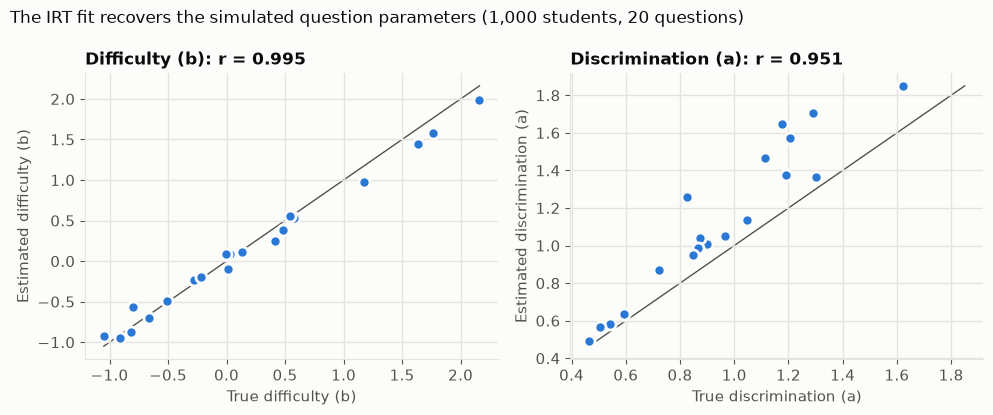

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, true, est, name in [(axes[0], true_b, fit.b, "Difficulty (b)"), (axes[1], true_a, fit.a, "Discrimination (a)")]:
    lo, hi = min(true.min(), est.min()), max(true.max(), est.max())
    ax.plot([lo, hi], [lo, hi], color=INK_2, linewidth=1, zorder=1)
    ax.scatter(true, est, s=64, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=2)
    ax.set_xlabel(f"True {name.lower()}")
    ax.set_ylabel(f"Estimated {name.lower()}")
    ax.set_title(f"{name}: r = {pearsonr(true, est)[0]:.3f}")
fig.suptitle("The IRT fit recovers the simulated question parameters (1,000 students, 20 questions)",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "02_irt_recovery.png", dpi=150)

## 2. Classical statistics against the truth

The analytics page uses classical test theory, not IRT, because it's easy to explain
and works with small classes. Easier questions (lower true *b*) should have higher
difficulty scores (share of points earned), and more discriminating questions (higher
true *a*) should have higher item-rest correlations.

In [4]:
stats = ia.test_statistics(cls.scores)
classical = pd.DataFrame({
    "comparison": ["difficulty vs true b", "item-rest correlation vs true a"],
    "spearman rho": [spearmanr(stats.difficulty, true_b)[0], spearmanr(stats.item_rest, true_a)[0]],
})
classical

,comparison,spearman rho
0,difficulty vs true b,-0.968
1,item-rest correlation vs true a,0.845


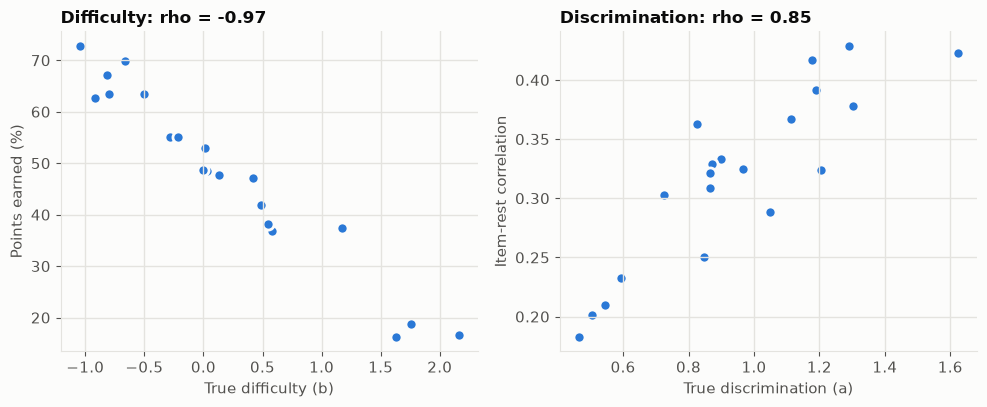

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].scatter(true_b, stats.difficulty * 100, s=64, color=BLUE, edgecolor=SURFACE, linewidth=2)
axes[0].set_xlabel("True difficulty (b)")
axes[0].set_ylabel("Points earned (%)")
axes[0].set_title(f"Difficulty: rho = {spearmanr(stats.difficulty, true_b)[0]:.2f}")
axes[1].scatter(true_a, stats.item_rest, s=64, color=BLUE, edgecolor=SURFACE, linewidth=2)
axes[1].set_xlabel("True discrimination (a)")
axes[1].set_ylabel("Item-rest correlation")
axes[1].set_title(f"Discrimination: rho = {spearmanr(stats.item_rest, true_a)[0]:.2f}")
fig.tight_layout()
fig.savefig(FIGURES / "02_classical_vs_true.png", dpi=150)

## 3. How often are the flags right?

Each simulated test has 20 multiple-choice questions with guessing, and three planted
problems: a **miskeyed** question (the key marks the wrong option), a **dead** wrong
option, and a very **easy** question. The truth for every question comes from its real
parameters (`simulate.true_flags`), so a question that happens to be naturally very easy
counts as a correct "easy" flag, not a false alarm.

- **Precision:** of the questions flagged, the share that really had the problem.
- **Recall:** of the questions that had the problem, the share that got flagged.

"Check the answer key" combines two signals: a negative item-rest correlation, and a
wrong option that strong students pick more than weak ones. QuizBank requires both to be
statistically significant (one-sided, 5%); the fixed version uses the raw cutoffs.

In [6]:
N_TESTS = 200
rows = []
for n_students in (30, 100, 300):
    for adaptive in (False, True):
        result = simulate.flag_accuracy(N_TESTS, n_students, seed=11, adaptive=adaptive)
        for problem, r in result.items():
            rows.append({"students": n_students, "thresholds": "significance" if adaptive else "fixed",
                         "flag": problem, "precision": r["precision"], "recall": r["recall"],
                         "flagged": r["tp"] + r["fp"], "actual": r["tp"] + r["fn"]})
accuracy = pd.DataFrame(rows)
accuracy.pivot_table(index=["flag", "thresholds"], columns="students", values=["precision", "recall"])

precision               recall              
students                    30     100    300    30     100    300
flag     thresholds                                               
dead     fixed            0.526  0.757  0.838  0.893  0.845  0.881
         significance     0.526  0.757  0.838  0.893  0.845  0.881
easy     fixed            0.774  0.858  0.931  0.695  0.841  0.923
         significance     0.774  0.858  0.931  0.695  0.841  0.923
miskeyed fixed            0.163  0.534  0.948  0.930  0.970  1.000
         significance     0.782  0.919  1.000  0.340  0.735  0.970

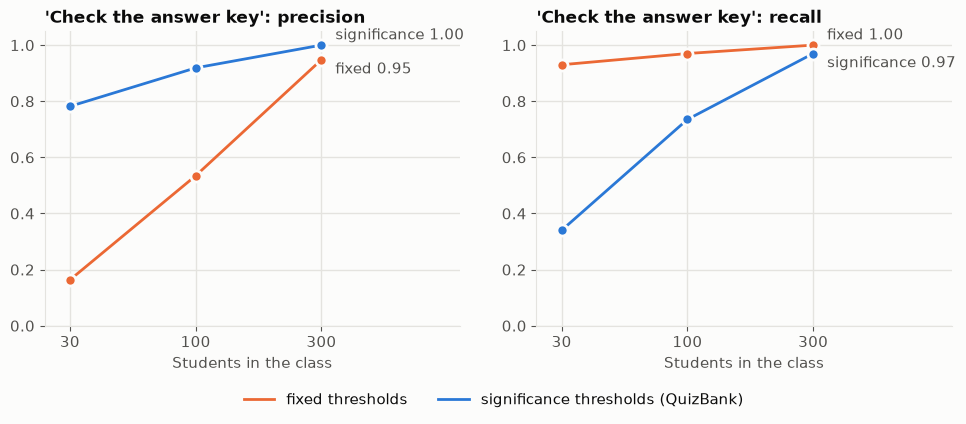

In [7]:
miskey = accuracy[accuracy.flag == "miskeyed"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)
sizes = [30, 100, 300]
for ax, metric in zip(axes, ("precision", "recall")):
    ends = {}
    for thresholds, color in (("fixed", ORANGE), ("significance", BLUE)):
        part = miskey[miskey.thresholds == thresholds].set_index("students").loc[sizes]
        ax.plot(range(3), part[metric], color=color, linewidth=2, marker="o", markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=2)
        ends[thresholds] = part[metric].iloc[-1]
    # End labels, pushed apart when the two lines finish close together.
    gap = ends["fixed"] - ends["significance"]
    for thresholds in ends:
        nudge = 0 if abs(gap) > 0.08 else (7 if (ends[thresholds] >= max(ends.values())) else -7)
        ax.annotate(f"{thresholds} {ends[thresholds]:.2f}", (2, ends[thresholds]), xytext=(10, nudge),
                    textcoords="offset points", va="center", color=INK_2)
    ax.set_xticks(range(3), [str(s) for s in sizes])
    ax.set_xlim(-0.2, 3.1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Students in the class")
    ax.set_title(f"'Check the answer key': {metric}")
fig.legend(handles=[plt.Line2D([], [], color=ORANGE, linewidth=2, label="fixed thresholds"),
                    plt.Line2D([], [], color=BLUE, linewidth=2, label="significance thresholds (QuizBank)")],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(FIGURES / "02_answer_key_flag.png", dpi=150)

In [8]:
summary = accuracy[accuracy.thresholds == "significance"].pivot_table(
    index="flag", columns="students", values=["precision", "recall"])
summary

precision               recall              
students       30     100    300    30     100    300
flag                                                 
dead         0.526  0.757  0.838  0.893  0.845  0.881
easy         0.774  0.858  0.931  0.695  0.841  0.923
miskeyed     0.782  0.919  1.000  0.340  0.735  0.970

## What this means for the app

With seeded simulations (the tables above are reproducible):

- **The simulation is faithful to the model.** The IRT fit recovers difficulty almost
  exactly (r = 0.995, RMSE 0.12 after rescaling) and discrimination well (r = 0.95),
  though it still overestimates the steepest questions a little, which is a known
  small-sample bias of joint estimation.
- **The classical statistics track the truth.** Share of points earned ranks questions
  by true difficulty with Spearman rho = -0.97, and the item-rest correlation ranks them
  by true discrimination with rho = 0.85.
- **"Check the answer key" needs significance tests.** With fixed cutoffs, only 16% of
  these flags were right in a class of 30, and 53% in a class of 100: most were noise.
  Requiring significance raised that to 78% and 92%, at the cost of catching fewer real
  problems in small classes (recall 34% at 30 students, 73% at 100, 97% at 300). For a
  flag that tells an instructor their key is wrong, false alarms cost more than misses,
  and a missed miskey still shows up as a "weak" question.
- **Small classes are genuinely hard.** Below about 100 students, every flag misses or
  mislabels some questions, which is why the analytics page warns that the numbers are
  noisy for small classes and calls flags hints rather than verdicts.